In [ ]:
# Install all required packages
! pip install -q pypdf pdfplumber faiss-cpu sentence-transformers langchain langchain-community langchain-google-genai langchain-openai google-generativeai openai tiktoken python-dotenv matplotlib pandas tqdm ipywidgets --trusted-host pypi.org --trusted-host  pypi.python.org --trusted-host files.pythonhosted.org

## Configuration & API Keys

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()  # Load from .env file if present

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION — edit these values or set them as environment variables
# ─────────────────────────────────────────────────────────────────────────────

# Path to your ML book PDF
PDF_PATH = "/home/savinay/Compliance_Modernization_Python/intro-to-ml.pdf"

LLM_PROVIDER = "gemini"               

# API Keys (set here OR in a .env file OR as environment variables)
GEMINI_API_KEY  = os.getenv("GEMINI_API_KEY",  "YOUR_GEMINI_API_KEY_HERE")

# Chunking parameters
CHUNK_SIZE      = 800    # tokens per chunk
CHUNK_OVERLAP   = 100    # overlap between consecutive chunks

# Retrieval parameters
TOP_K           = 5      # default number of chunks to retrieve

# Embedding model (SentenceTransformers — runs locally, no API key needed)
EMBEDDING_MODEL = "all-MiniLM-L6-v2"

# LLM model names
GEMINI_MODEL    = "gemini-2.5-flash"

# Set API keys in environment
os.environ["GOOGLE_API_KEY"] = GEMINI_API_KEY

print(" Configuration loaded.")
print(f"   LLM Provider  : {LLM_PROVIDER}")
print(f"   Chunk Size    : {CHUNK_SIZE} tokens")
print(f"   Chunk Overlap : {CHUNK_OVERLAP} tokens")
print(f"   Top-K Retrieval: {TOP_K}")
print(f"   Embedding Model: {EMBEDDING_MODEL}")

✅ Configuration loaded.
   LLM Provider  : gemini
   Chunk Size    : 800 tokens
   Chunk Overlap : 100 tokens
   Top-K Retrieval: 5
   Embedding Model: all-MiniLM-L6-v2


---
# Part 1 — Data Understanding & Preprocessing

## 1.1 — Load & Explore the PDF

In [4]:
import pdfplumber
import pypdf
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# ─── Load PDF with pdfplumber for rich extraction ───────────────────────────
print(f"📖 Loading PDF: {PDF_PATH}")

pages_raw = []  # list of dicts: {page_num, text, char_count, word_count}

with pdfplumber.open(PDF_PATH) as pdf:
    total_pages = len(pdf.pages)
    print(f"   Total pages: {total_pages}")
    
    for i, page in enumerate(pdf.pages):
        text = page.extract_text() or ""  # returns None for image-only pages
        pages_raw.append({
            "page_num"   : i + 1,
            "text"       : text,
            "char_count" : len(text),
            "word_count" : len(text.split()),
        })

df_pages = pd.DataFrame(pages_raw)
print("\n📊 Page-level statistics:")
print(df_pages[["char_count", "word_count"]].describe().round(1).to_string())

Matplotlib is building the font cache; this may take a moment.


📖 Loading PDF: /home/savinay/Compliance_Modernization_Python/intro-to-ml.pdf
   Total pages: 392

📊 Page-level statistics:
       char_count  word_count
count       392.0       392.0
mean       1708.6       263.0
std         668.8       111.6
min           0.0         0.0
25%        1257.5       187.0
50%        1789.0       264.0
75%        2181.5       339.0
max        3246.0       565.0


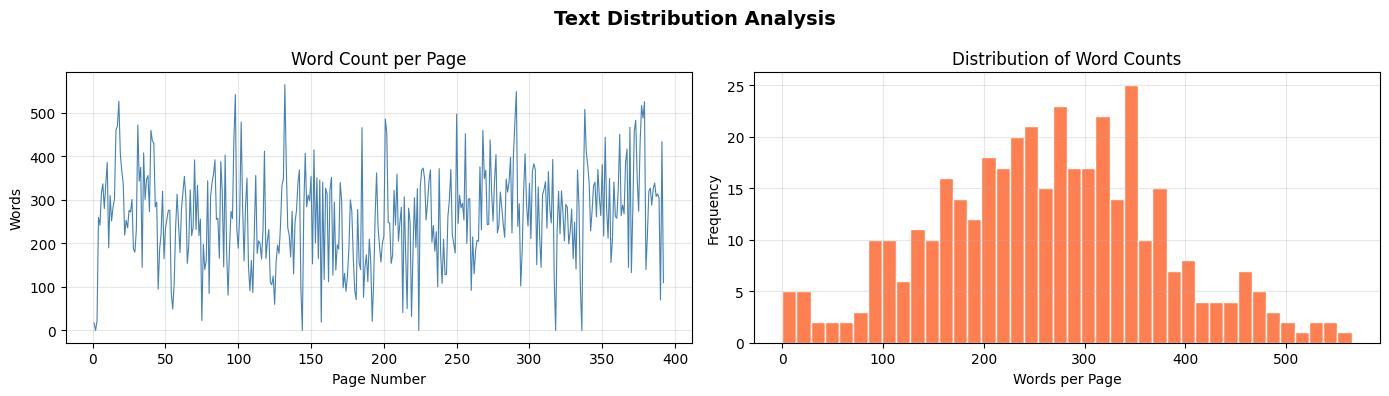

Figure saved → page_text_distribution.png


In [5]:
# ─── Visualise text distribution across pages ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df_pages["page_num"], df_pages["word_count"], linewidth=0.8, color="steelblue")
axes[0].set_title("Word Count per Page")
axes[0].set_xlabel("Page Number")
axes[0].set_ylabel("Words")
axes[0].grid(alpha=0.3)

axes[1].hist(df_pages["word_count"], bins=40, color="coral", edgecolor="white")
axes[1].set_title("Distribution of Word Counts")
axes[1].set_xlabel("Words per Page")
axes[1].set_ylabel("Frequency")
axes[1].grid(alpha=0.3)

plt.suptitle("Text Distribution Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("page_text_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → page_text_distribution.png")

In [6]:
# ─── Identify text quality issues ───────────────────────────────────────────
empty_pages  = df_pages[df_pages["word_count"] == 0]
sparse_pages = df_pages[(df_pages["word_count"] > 0) & (df_pages["word_count"] < 20)]
rich_pages   = df_pages[df_pages["word_count"] >= 20]

print("📋 Text Quality Report")
print(f"   Total pages       : {total_pages}")
print(f"   Empty pages       : {len(empty_pages)}  (image-only or blank)")
print(f"   Sparse pages (<20w): {len(sparse_pages)}")
print(f"   Content pages     : {len(rich_pages)}")
print(f"   Total words       : {df_pages['word_count'].sum():,}")
print(f"   Total characters  : {df_pages['char_count'].sum():,}")

# Preview a sample page
sample_page = df_pages[df_pages["word_count"] > 100].iloc[5]
print(f"\n📄 Sample text from page {sample_page['page_num']}:")
print("-" * 60)
print(sample_page["text"][:500], "...")

📋 Text Quality Report
   Total pages       : 392
   Empty pages       : 5  (image-only or blank)
   Sparse pages (<20w): 2
   Content pages     : 385
   Total words       : 103,087
   Total characters  : 669,775

📄 Sample text from page 9:
------------------------------------------------------------
Preface
Machine learning is an integral part of many commercial applications and research
projects today, in areas ranging from medical diagnosis and treatment to finding your
friends on social networks. Many people think that machine learning can only be
applied by large companies with extensive research teams. In this book, we want to
show you how easy it can be to build machine learning solutions yourself, and how to
best go about it. With the knowledge in this book, you can build your own sy ...


## 1.2 — Text Cleaning

In [ ]:
def clean_text(text: str) -> str:
    """
    Clean extracted PDF text:
    - Remove excessive whitespace / newlines
    - Fix hyphenated line-breaks (e.g. 'neu-\nral' → 'neural')
    - Remove page numbers standing alone
    - Collapse multiple spaces
    """
    # Fix hyphenated line breaks
    text = re.sub(r"(\w)-\n(\w)", r"\1\2", text)
    # Join soft-wrapped lines (line ending without punctuation)
    text = re.sub(r"(?<!\.)\n(?![\n\•\-\d])", " ", text)
    # Remove standalone page numbers
    text = re.sub(r"\n\s*\d{1,4}\s*\n", "\n", text)
    # Collapse whitespace
    text = re.sub(r"[ \t]+", " ", text)
    # Collapse excess blank lines
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


# Apply cleaning to all pages
df_pages["clean_text"] = df_pages["text"].apply(clean_text)

# Build a single full-document string (useful for statistics)
full_text = "\n\n".join(
    f"[PAGE {row.page_num}]\n{row.clean_text}"
    for row in df_pages.itertuples()
    if row.word_count > 10
)

print(f"Cleaning complete.")
print(f"   Full document length: {len(full_text):,} characters")

✅ Cleaning complete.
   Full document length: 674,596 characters


## 1.3 — Chunking Strategy

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.schema import Document
from tqdm import tqdm

# ─── Build LangChain Document objects (one per page) ─────────────────────────
documents = [
    Document(
        page_content=row["clean_text"],
        metadata={"page": row["page_num"], "source": PDF_PATH}
    )
    for _, row in df_pages.iterrows()
    if row["word_count"] > 10
]

print(f"Documents created: {len(documents)} pages")

# ─── Splitter configuration ──────────────────────────────────────────────────
splitter = RecursiveCharacterTextSplitter(
    chunk_size    = CHUNK_SIZE,
    chunk_overlap = CHUNK_OVERLAP,
    separators    = ["\n\n", "\n", ". ", " ", ""],
    length_function = len,
)

chunks = splitter.split_documents(documents)

chunk_lengths = [len(c.page_content) for c in chunks]

print(f"\n Chunking complete.")
print(f"   Total chunks     : {len(chunks)}")
print(f"   Avg chunk length : {sum(chunk_lengths)//len(chunk_lengths)} chars")
print(f"   Min chunk length : {min(chunk_lengths)} chars")
print(f"   Max chunk length : {max(chunk_lengths)} chars")

Documents created: 387 pages

✅ Chunking complete.
   Total chunks     : 1368
   Avg chunk length : 498 chars
   Min chunk length : 3 chars
   Max chunk length : 800 chars


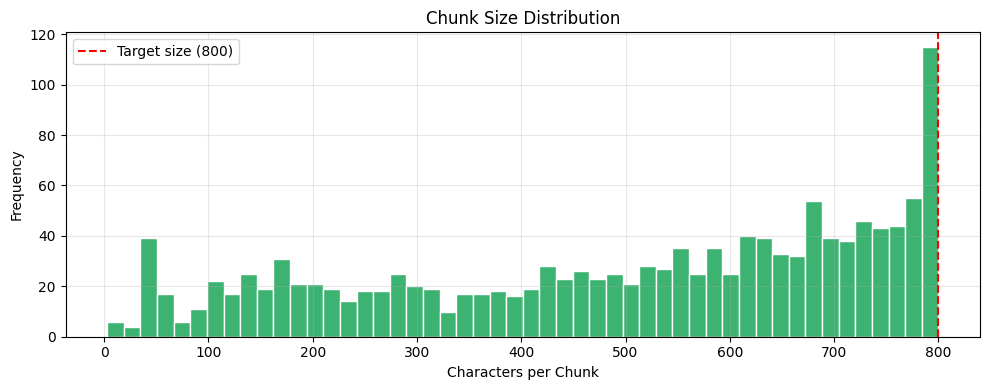


📄 Sample Chunk #1:
------------------------------------------------------------
Introduction to Machine Learning with Python A GUIDE FOR DATA SCIENTISTS Andreas C. Müller & Sarah Guido
  [Metadata: {'page': 1, 'source': '/home/savinay/Compliance_Modernization_Python/intro-to-ml.pdf'}]

📄 Sample Chunk #50:
------------------------------------------------------------
For both supervised and unsupervised learning tasks, it is important to have a repre‐ sentation of your input data that a computer can understand. Often it is helpful to think of your data as a table. Each data point that you want to reason about (each email, each customer, each transaction) is a row, and each property that describes that data point (say, the age of a customer or the amount or loc


In [ ]:
# ─── Visualise chunk size distribution ───────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.hist(chunk_lengths, bins=50, color="mediumseagreen", edgecolor="white")
plt.axvline(CHUNK_SIZE, color="red", linestyle="--", label=f"Target size ({CHUNK_SIZE})")
plt.title("Chunk Size Distribution")
plt.xlabel("Characters per Chunk")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("chunk_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Print sample chunks
print("\n Sample Chunk #1:")
print("-" * 60)
print(chunks[0].page_content[:400])
print(f"  [Metadata: {chunks[0].metadata}]")

print("\n Sample Chunk #50:")
print("-" * 60)
print(chunks[min(50, len(chunks)-1)].page_content[:400])

---
# Part 2 — Embedding & Vector Database

## 2.1 — Generate Embeddings

In [10]:
from sentence_transformers import SentenceTransformer
import numpy as np
import time

print(f" Loading embedding model: {EMBEDDING_MODEL}")
embed_model = SentenceTransformer(EMBEDDING_MODEL)

# Extract raw text from chunks
chunk_texts = [c.page_content for c in chunks]

print(f" Encoding {len(chunk_texts)} chunks...")
start = time.time()

embeddings = embed_model.encode(
    chunk_texts,
    batch_size     = 64,
    show_progress_bar = True,
    normalize_embeddings = True,   # L2 normalise → cosine sim = dot product
    convert_to_numpy = True,
)

elapsed = time.time() - start

print(f"\n Embedding complete.")
print(f"   Embedding matrix shape : {embeddings.shape}")
print(f"   Embedding dimension    : {embeddings.shape[1]}")
print(f"   Time taken             : {elapsed:.1f}s  ({len(chunk_texts)/elapsed:.0f} chunks/sec)")

🔄 Loading embedding model: all-MiniLM-L6-v2
🔄 Encoding 1368 chunks...


Batches:   0%|          | 0/22 [00:00<?, ?it/s]


✅ Embedding complete.
   Embedding matrix shape : (1368, 384)
   Embedding dimension    : 384
   Time taken             : 30.1s  (45 chunks/sec)


## 2.2 — Store in FAISS Vector Database

In [ ]:
import faiss
import pickle

EMBED_DIM = embeddings.shape[1]

# ─── Build FAISS index (Inner Product = cosine for normalised vectors) ────────
index = faiss.IndexFlatIP(EMBED_DIM)       # exact search
index.add(embeddings.astype(np.float32))

print(f" FAISS index built.")
print(f"   Index type  : IndexFlatIP (exact cosine similarity)")
print(f"   Vectors     : {index.ntotal}")
print(f"   Dimension   : {EMBED_DIM}")

# ─── Persist index and chunk metadata to disk ────────────────────────────────
faiss.write_index(index, "ml_book_faiss.index")

with open("ml_book_chunks.pkl", "wb") as f:
    pickle.dump(chunks, f)

print("\n Index saved → ml_book_faiss.index")
print(" Chunks saved → ml_book_chunks.pkl")

## 2.3 — Similarity Search Demo

In [ ]:
def retrieve_chunks(query: str, k: int = TOP_K, verbose: bool = True):
    """
    Convert a query to an embedding and retrieve the top-k most similar chunks.
    Returns a list of (chunk, score) tuples.
    """
    # Embed and normalise the query
    q_vec = embed_model.encode(
        [query], normalize_embeddings=True, convert_to_numpy=True
    ).astype(np.float32)

    # FAISS search
    scores, indices = index.search(q_vec, k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx == -1:  # FAISS returns -1 for empty slots
            continue
        results.append((chunks[idx], float(score)))

    if verbose:
        print(f"\n🔍 Query: '{query}'")
        print(f"   Retrieved {len(results)} chunks (k={k})")
        print("-" * 70)
        for rank, (chunk, score) in enumerate(results, 1):
            print(f"[Rank {rank}] Score: {score:.4f}  |  Page: {chunk.metadata['page']}")
            print(chunk.page_content[:250].replace("\n", " ") + "...")
            print()

    return results


# ─── Demo retrieval ───────────────────────────────────────────────────────────
sample_results = retrieve_chunks("What is gradient descent and how does it work?")

---
# Part 3 — Retrieval Pipeline

## 3.1 — Retrieval Pipeline Class

In [ ]:
class RetrievalPipeline:
    """
    Encapsulates the full retrieval workflow:
      1. Embed query
      2. Search FAISS index
      3. Return ranked chunks with metadata
    """

    def __init__(self, faiss_index, chunk_list, embed_model):
        self.index      = faiss_index
        self.chunks     = chunk_list
        self.model      = embed_model

    def retrieve(self, query: str, k: int = 5) -> list:
        """Return top-k (chunk, score) pairs for the query."""
        q_vec = self.model.encode(
            [query], normalize_embeddings=True, convert_to_numpy=True
        ).astype(np.float32)
        scores, indices = self.index.search(q_vec, k)
        return [
            {"chunk": self.chunks[idx], "score": float(score), "rank": rank + 1}
            for rank, (score, idx) in enumerate(zip(scores[0], indices[0]))
            if idx != -1
        ]

    def format_context(self, results: list) -> str:
        """Concatenate retrieved chunks into a single context string."""
        parts = []
        for r in results:
            page = r["chunk"].metadata["page"]
            parts.append(f"[Source: Page {page} | Relevance: {r['score']:.3f}]\n{r['chunk'].page_content}")
        return "\n\n---\n\n".join(parts)


# Instantiate the pipeline
retrieval_pipeline = RetrievalPipeline(index, chunks, embed_model)
print(" RetrievalPipeline ready.")

## 3.2 — Experiment: Effect of k on Retrieval

In [ ]:
test_query = "Explain how backpropagation trains a neural network"

for k_val in [3, 5, 7]:
    results = retrieval_pipeline.retrieve(test_query, k=k_val)
    print(f"\n{'='*65}")
    print(f" k = {k_val}  |  Query: '{test_query}'")
    print(f"{'='*65}")
    for r in results:
        preview = r["chunk"].page_content[:180].replace("\n", " ")
        print(f"  Rank {r['rank']} | Score: {r['score']:.4f} | Page {r['chunk'].metadata['page']}")
        print(f"  {preview}...")
        print()

In [ ]:
# ─── Visualise score drop-off with increasing k ───────────────────────────────
results_k7 = retrieval_pipeline.retrieve(test_query, k=7)
ranks  = [r["rank"] for r in results_k7]
scores = [r["score"] for r in results_k7]

plt.figure(figsize=(8, 4))
plt.bar(ranks, scores, color="dodgerblue", edgecolor="white")
plt.title(f"Retrieval Score by Rank (k=7)")
plt.xlabel("Rank")
plt.ylabel("Cosine Similarity Score")
plt.xticks(ranks)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("retrieval_scores.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n Observation: Scores drop off with rank, confirming semantic relevance ordering.")

---
# Part 4 — Answer Generation (RAG)

## 4.1 — LLM Setup

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langchain.schema import HumanMessage, SystemMessage

def get_llm():
    """Initialise the LLM based on LLM_PROVIDER config."""
    if LLM_PROVIDER == "gemini":
        return ChatGoogleGenerativeAI(
            model       = GEMINI_MODEL,
            temperature = 0.1,           # low temp → more factual
            google_api_key = GEMINI_API_KEY,
        )
    elif LLM_PROVIDER == "openai":
        return ChatOpenAI(
            model       = OPENAI_MODEL,
            temperature = 0.1,
            api_key     = OPENAI_API_KEY,
        )
    else:
        raise ValueError(f"Unknown LLM_PROVIDER: {LLM_PROVIDER}")


llm = get_llm()
print(f" LLM initialised: {LLM_PROVIDER} / {GEMINI_MODEL if LLM_PROVIDER == 'gemini' else OPENAI_MODEL}")

## 4.2 — Prompt Template

In [ ]:
RAG_SYSTEM_PROMPT = """You are an expert Machine Learning teaching assistant.
Your role is to answer questions **strictly based on the provided context excerpts** from a Machine Learning textbook.

Rules:
1. Use ONLY the information present in the context below. Do NOT use external knowledge.
2. If the answer cannot be found in the context, say: "The provided context does not contain enough information to answer this question."
3. Always cite the source page number(s) when referencing specific facts.
4. Be concise, clear, and technically accurate.
5. Use bullet points or numbered steps where appropriate."""


def build_prompt(question: str, context: str) -> str:
    """
    Construct the full RAG prompt.
    """
    return f"""CONTEXT FROM TEXTBOOK:
======================
{context}
======================

QUESTION: {question}

Please provide a detailed answer based solely on the context above. 
Cite specific page numbers where relevant."""


print(" Prompt template defined.")
print("\n System Prompt:")
print(RAG_SYSTEM_PROMPT)

## 4.3 — RAG Answer Generator

In [ ]:
def rag_answer(question: str, k: int = TOP_K, show_context: bool = False) -> dict:
    """
    Full RAG pipeline:
      1. Retrieve top-k chunks
      2. Build prompt
      3. Generate answer with LLM

    Returns dict with answer, context, and retrieval metadata.
    """
    # Step 1: Retrieve
    retrieved = retrieval_pipeline.retrieve(question, k=k)
    context   = retrieval_pipeline.format_context(retrieved)

    # Step 2: Build messages
    messages = [
        SystemMessage(content=RAG_SYSTEM_PROMPT),
        HumanMessage(content=build_prompt(question, context)),
    ]

    # Step 3: Generate
    response = llm.invoke(messages)
    answer   = response.content

    # Optionally print full context
    if show_context:
        print("\n📚 RETRIEVED CONTEXT:")
        print("-" * 60)
        print(context[:1500], "..." if len(context) > 1500 else "")

    return {
        "question"  : question,
        "answer"    : answer,
        "context"   : context,
        "sources"   : [r["chunk"].metadata["page"] for r in retrieved],
        "scores"    : [round(r["score"], 4) for r in retrieved],
    }


print("✅ rag_answer() function ready.")

## 4.4 — Sample Queries & Generated Answers

In [ ]:
# ─── Query 1 ─────────────────────────────────────────────────────────────────
q1 = "What is gradient descent and what are its variants?"
result1 = rag_answer(q1, k=5)

print(f"\n{'='*70}")
print(f"❓ Q1: {result1['question']}")
print(f"{'='*70}")
print(f"\n📖 ANSWER:\n")
print(result1["answer"])
print(f"\n📌 Sources (pages): {result1['sources']}")
print(f"📊 Retrieval scores: {result1['scores']}")

In [ ]:
# ─── Query 2 ─────────────────────────────────────────────────────────────────
q2 = "How does a Random Forest differ from a single Decision Tree?"
result2 = rag_answer(q2, k=5)

print(f"\n{'='*70}")
print(f"❓ Q2: {result2['question']}")
print(f"{'='*70}")
print(f"\n📖 ANSWER:\n")
print(result2["answer"])
print(f"\n📌 Sources (pages): {result2['sources']}")

In [ ]:
# ─── Query 3 ─────────────────────────────────────────────────────────────────
q3 = "Explain overfitting and regularisation techniques used to prevent it."
result3 = rag_answer(q3, k=5)

print(f"\n{'='*70}")
print(f"❓ Q3: {result3['question']}")
print(f"{'='*70}")
print(f"\n📖 ANSWER:\n")
print(result3["answer"])
print(f"\n📌 Sources (pages): {result3['sources']}")

In [ ]:
# ─── Query 4 ─────────────────────────────────────────────────────────────────
q4 = "What is the role of the activation function in a neural network?"
result4 = rag_answer(q4, k=5)

print(f"\n{'='*70}")
print(f"❓ Q4: {result4['question']}")
print(f"{'='*70}")
print(f"\n📖 ANSWER:\n")
print(result4["answer"])
print(f"\n📌 Sources (pages): {result4['sources']}")

In [ ]:
# ─── Query 5 — Hallucination guard test ───────────────────────────────────────
q5 = "What is the recipe for chocolate cake?"
result5 = rag_answer(q5, k=5)

print(f"\n{'='*70}")
print(f"❓ Q5 (out-of-scope): {result5['question']}")
print(f"{'='*70}")
print(f"\n📖 ANSWER (should refuse gracefully):\n")
print(result5["answer"])
print("\n✅ Grounding check: Model should indicate no relevant context.")

### Evidence of Grounding

---
# Part 5 — End-to-End RAG Application

## 5.1 — Full RAG Application Class

In [ ]:
class MLBookRAG:
    """
    End-to-end RAG system for a Machine Learning textbook.
    
    Pipeline:
        PDF → Text → Chunks → Embeddings → FAISS
        Query → Embedding → Retrieval → LLM → Answer
    """

    def __init__(
        self,
        faiss_index,
        chunk_list,
        embed_model,
        llm,
        default_k: int = 5,
    ):
        self.retrieval = RetrievalPipeline(faiss_index, chunk_list, embed_model)
        self.llm       = llm
        self.default_k = default_k
        self.history   = []   # stores Q&A history for session

        print("✅ MLBookRAG application initialised.")
        print(f"   Vector store : {faiss_index.ntotal} chunks indexed")
        print(f"   Default k    : {default_k}")

    # ──────────────────────────────────────────────────────────────────────────
    def ask(self, question: str, k: int = None, show_sources: bool = True) -> str:
        """
        Main public method: accepts a question, retrieves context,
        generates and prints a grounded answer.
        """
        k = k or self.default_k

        # Retrieve
        retrieved = self.retrieval.retrieve(question, k=k)
        context   = self.retrieval.format_context(retrieved)

        # Generate
        messages = [
            SystemMessage(content=RAG_SYSTEM_PROMPT),
            HumanMessage(content=build_prompt(question, context)),
        ]
        response = self.llm.invoke(messages)
        answer   = response.content

        # Format output
        pages = sorted(set(r["chunk"].metadata["page"] for r in retrieved))
        self._print_response(question, answer, pages, show_sources)

        # Save to history
        self.history.append({"question": question, "answer": answer, "pages": pages})
        return answer

    # ──────────────────────────────────────────────────────────────────────────
    def _print_response(self, question, answer, pages, show_sources):
        border = "═" * 70
        print(f"\n{border}")
        print(f"❓  {question}")
        print(f"{border}")
        print(f"\n{answer}")
        if show_sources:
            print(f"\n{'─'*70}")
            print(f"📚 Sources: Book pages {pages}")
        print(f"{border}\n")

    # ──────────────────────────────────────────────────────────────────────────
    def show_history(self):
        """Print a summary of all questions answered this session."""
        if not self.history:
            print("No questions answered yet.")
            return
        print(f"\n📜 Session History ({len(self.history)} questions)")
        for i, item in enumerate(self.history, 1):
            print(f"  {i}. {item['question']}  [pages: {item['pages']}]")

    # ──────────────────────────────────────────────────────────────────────────
    def interactive(self):
        """
        Launch an interactive Q&A loop in the notebook.
        Type 'quit' or 'exit' to stop. Type 'history' to see past questions.
        """
        print("\n" + "═"*60)
        print("  🤖  ML Book RAG — Interactive Q&A")
        print("  Type your question and press Enter.")
        print("  Commands: 'history' | 'quit'")
        print("═"*60)

        while True:
            try:
                user_input = input("\n🙋 Your question: ").strip()
            except (EOFError, KeyboardInterrupt):
                print("\n👋 Session ended.")
                break

            if not user_input:
                continue
            if user_input.lower() in ("quit", "exit"):
                print("👋 Goodbye!")
                break
            if user_input.lower() == "history":
                self.show_history()
                continue

            self.ask(user_input)


# Instantiate the full application
rag_app = MLBookRAG(
    faiss_index = index,
    chunk_list  = chunks,
    embed_model = embed_model,
    llm         = llm,
    default_k   = TOP_K,
)

## 5.2 — Demonstration of Multiple Queries

In [ ]:
# ─── Run a demonstration batch ────────────────────────────────────────────────
demo_questions = [
    "What is the bias-variance tradeoff?",
    "How does the support vector machine algorithm work?",
    "What is dropout and why is it used in deep learning?",
    "Describe the architecture of a convolutional neural network.",
    "What is the difference between supervised and unsupervised learning?",
]

for q in demo_questions:
    rag_app.ask(q, k=5)

In [ ]:
# ─── View session history ─────────────────────────────────────────────────────
rag_app.show_history()

## 5.3 — Interactive Q&A Widget (Notebook UI)

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# ─── Widget components ────────────────────────────────────────────────────────
title_html = widgets.HTML(
    value="<h2 style='color:#2c3e50;font-family:sans-serif;'>🤖 ML Book RAG — Q&A Assistant</h2>"
)

question_input = widgets.Textarea(
    placeholder="Type your machine learning question here...",
    layout=widgets.Layout(width="100%", height="80px"),
)

k_slider = widgets.IntSlider(
    value=TOP_K, min=1, max=10, step=1,
    description="Top-k:",
    style={"description_width": "initial"},
)

ask_button = widgets.Button(
    description="🔍 Ask",
    button_style="primary",
    layout=widgets.Layout(width="120px", height="40px"),
)

clear_button = widgets.Button(
    description="🗑️ Clear",
    button_style="warning",
    layout=widgets.Layout(width="120px", height="40px"),
)

output_area = widgets.Output(
    layout=widgets.Layout(
        border="1px solid #ddd",
        min_height="200px",
        padding="10px",
        overflow_y="auto",
        max_height="600px",
    )
)

status_label = widgets.Label(value="Ready.")

# ─── Button callbacks ─────────────────────────────────────────────────────────
def on_ask_clicked(b):
    question = question_input.value.strip()
    if not question:
        status_label.value = "⚠️  Please enter a question."
        return
    k = k_slider.value
    status_label.value = f"⏳ Searching {k} chunks and generating answer..."

    with output_area:
        print(f"\n{'─'*60}")
        print(f"❓ {question}")
        print(f"{'─'*60}")
        try:
            answer = rag_app.ask(question, k=k, show_sources=True)
        except Exception as e:
            print(f"❌ Error: {e}")
    status_label.value = "✅ Done."


def on_clear_clicked(b):
    with output_area:
        clear_output()
    status_label.value = "Cleared."


ask_button.on_click(on_ask_clicked)
clear_button.on_click(on_clear_clicked)

# ─── Layout & display ─────────────────────────────────────────────────────────
controls = widgets.HBox([ask_button, clear_button, k_slider])
ui = widgets.VBox([
    title_html,
    widgets.Label("Your Question:"),
    question_input,
    controls,
    status_label,
    widgets.Label("Answer:"),
    output_area,
])

display(ui)

## 5.4 — Terminal-Style Interactive Loop

---
# Summary & Analysis

In [ ]:
# ─── Final statistics ─────────────────────────────────────────────────────────
print("📊 Final Pipeline Statistics")
print(f"   PDF pages processed   : {len(df_pages):,}")
print(f"   Content pages         : {len(df_pages[df_pages.word_count > 10]):,}")
print(f"   Total chunks          : {len(chunks):,}")
print(f"   Avg chunk size        : {sum(chunk_lengths)//len(chunk_lengths)} chars")
print(f"   Embedding dimension   : {EMBED_DIM}")
print(f"   FAISS vectors indexed : {index.ntotal:,}")
print(f"   Queries answered      : {len(rag_app.history)}")
print(f"   Session questions     :")
for i, h in enumerate(rag_app.history, 1):
    print(f"     {i}. {h['question'][:65]}..." if len(h['question']) > 65 else f"     {i}. {h['question']}")